# Calculate phastCons 100-way Scores for Protein-Coding Genes

This notebook calculates phastCons conservation scores for all protein-coding genes in GENCODE v19 (hg19).

**Input files:**
- GENCODE v19 GTF: `/home/jw3514/Work/Resources/gencode.v19.annotation.gtf.gz`
- phastCons 100-way BigWig: `/home/jw3514/Work/Resources/hg19.100way.phastCons.bw`

**Strategy:**
1. Parse GTF to extract all CDS regions for protein-coding genes
2. Merge CDS coordinates (union across all transcripts per gene)
3. Calculate mean, median, and max phastCons scores across merged CDS
4. Map Ensembl gene IDs to Entrez IDs and gene symbols
5. Export results

**Output:**
- CSV with columns: EntrezID, GeneSymbol, EnsemblID, mean_phastCons, median_phastCons, max_phastCons, n_CDS_bases

In [14]:
import gzip
import pandas as pd
import numpy as np
import pyBigWig
from collections import defaultdict
from tqdm.auto import tqdm
import mygene
import warnings
warnings.filterwarnings('ignore')

print(f"pyBigWig version: {pyBigWig.__version__}")
print(f"pandas version: {pd.__version__}")


%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')


try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:  
    print(f"Unexpected error: {e}")    

pyBigWig version: 0.3.24
pandas version: 2.3.3
Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


## Step 1: Parse GENCODE v19 GTF and Extract CDS Regions

In [2]:
# File paths
GTF_FILE = "/home/jw3514/Work/Resources/gencode.v19.annotation.gtf.gz"
PHASTCONS_FILE = "/home/jw3514/Work/Resources/hg19.100way.phastCons.bw"
OUTPUT_FILE = "../results/phastCons_scores_all_genes.csv"

print(f"GTF file: {GTF_FILE}")
print(f"phastCons file: {PHASTCONS_FILE}")
print(f"Output file: {OUTPUT_FILE}")

GTF file: /home/jw3514/Work/Resources/gencode.v19.annotation.gtf.gz
phastCons file: /home/jw3514/Work/Resources/hg19.100way.phastCons.bw
Output file: ../results/phastCons_scores_all_genes.csv


In [3]:
def parse_gtf_attributes(attr_string):
    """Parse GTF attribute string into a dictionary."""
    attrs = {}
    for item in attr_string.strip().split(';'):
        item = item.strip()
        if item:
            key, value = item.split(' ', 1)
            attrs[key] = value.strip('"')
    return attrs

def extract_cds_regions(gtf_file):
    """
    Extract all CDS regions for protein-coding genes from GENCODE GTF.
    Returns a dictionary: {gene_id: {'symbol': str, 'chr': str, 'cds': [(start, end), ...]}}
    """
    gene_data = defaultdict(lambda: {'symbol': None, 'chr': None, 'cds': []})
    
    print("Parsing GTF file...")
    with gzip.open(gtf_file, 'rt') as f:
        for line in tqdm(f, desc="Reading GTF"):
            if line.startswith('#'):
                continue
            
            fields = line.strip().split('\t')
            if len(fields) < 9:
                continue
            
            chrom, source, feature, start, end, score, strand, frame, attributes = fields
            
            # Parse attributes
            attrs = parse_gtf_attributes(attributes)
            
            # Only process protein-coding genes
            if attrs.get('gene_type') != 'protein_coding':
                continue
            
            gene_id = attrs.get('gene_id', '').split('.')[0]  # Remove version
            
            # Extract CDS regions
            if feature == 'CDS':
                gene_data[gene_id]['chr'] = chrom
                gene_data[gene_id]['symbol'] = attrs.get('gene_name', gene_id)
                gene_data[gene_id]['cds'].append((int(start), int(end)))
    
    print(f"\nFound {len(gene_data)} protein-coding genes with CDS annotations")
    return dict(gene_data)

# Extract CDS regions
gene_cds_data = extract_cds_regions(GTF_FILE)

Parsing GTF file...


Reading GTF: 2619449it [00:17, 146187.10it/s]


Found 20345 protein-coding genes with CDS annotations


In [4]:
# Check the first few genes
print("Sample of extracted genes:")
for i, (gene_id, data) in enumerate(list(gene_cds_data.items())[:3]):
    print(f"\n{gene_id} ({data['symbol']}):")
    print(f"  Chromosome: {data['chr']}")
    print(f"  Number of CDS regions: {len(data['cds'])}")
    print(f"  First 3 CDS: {data['cds'][:3]}")

Sample of extracted genes:

ENSG00000186092 (OR4F5):
  Chromosome: chr1
  Number of CDS regions: 1
  First 3 CDS: [(69091, 70005)]

ENSG00000237683 (AL627309.1):
  Chromosome: chr1
  Number of CDS regions: 1
  First 3 CDS: [(138533, 139309)]

ENSG00000235249 (OR4F29):
  Chromosome: chr1
  Number of CDS regions: 1
  First 3 CDS: [(367659, 368594)]


## Step 2: Merge CDS Regions (Union Across Transcripts)

In [5]:
def merge_intervals(intervals):
    """
    Merge overlapping intervals.
    Input: list of (start, end) tuples
    Output: list of merged (start, end) tuples
    """
    if not intervals:
        return []
    
    # Sort by start position
    sorted_intervals = sorted(intervals, key=lambda x: x[0])
    
    merged = [sorted_intervals[0]]
    for current in sorted_intervals[1:]:
        last = merged[-1]
        if current[0] <= last[1]:  # Overlapping
            merged[-1] = (last[0], max(last[1], current[1]))
        else:
            merged.append(current)
    
    return merged

# Merge CDS regions for each gene
print("Merging CDS regions...")
for gene_id in tqdm(gene_cds_data.keys(), desc="Merging CDS"):
    gene_cds_data[gene_id]['merged_cds'] = merge_intervals(gene_cds_data[gene_id]['cds'])

print("\nMerging complete!")
print("\nExample - before and after merging:")
example_gene = list(gene_cds_data.keys())[0]
print(f"Gene: {example_gene} ({gene_cds_data[example_gene]['symbol']})")
print(f"  Original CDS count: {len(gene_cds_data[example_gene]['cds'])}")
print(f"  Merged CDS count: {len(gene_cds_data[example_gene]['merged_cds'])}")

Merging CDS regions...


Merging CDS: 100%|██████████| 20345/20345 [00:00<00:00, 61069.70it/s]


Merging complete!

Example - before and after merging:
Gene: ENSG00000186092 (OR4F5)
  Original CDS count: 1
  Merged CDS count: 1


## Step 3: Calculate phastCons Scores

For each gene's merged CDS regions, we'll extract phastCons scores and calculate:
- **Mean**: Average conservation across all CDS bases
- **Median**: Median conservation score
- **Max**: Maximum conservation score
- **Total CDS length**: Number of bases in merged CDS

In [6]:
# Open phastCons BigWig file
print(f"Opening phastCons file: {PHASTCONS_FILE}")
bw = pyBigWig.open(PHASTCONS_FILE)
print(f"Chromosomes in BigWig: {list(bw.chroms().keys())[:10]}...")  # Show first 10

Opening phastCons file: /home/jw3514/Work/Resources/hg19.100way.phastCons.bw
Chromosomes in BigWig: ['chr1', 'chr10', 'chr11', 'chr11_gl000202_random', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17']...


In [7]:
def calculate_phastcons_for_gene(gene_id, gene_info, bw_file):
    """
    Calculate phastCons scores for a gene's merged CDS regions.
    Returns: dict with mean, median, max phastCons and total CDS length
    """
    chrom = gene_info['chr']
    merged_cds = gene_info['merged_cds']
    
    if not merged_cds:
        return {'mean': np.nan, 'median': np.nan, 'max': np.nan, 'n_bases': 0}
    
    # Collect all phastCons values across merged CDS
    all_scores = []
    total_bases = 0
    
    for start, end in merged_cds:
        try:
            # pyBigWig uses 0-based coordinates, GTF is 1-based
            # Convert GTF 1-based to 0-based
            scores = bw_file.values(chrom, start - 1, end)
            
            # Filter out None values (regions without data)
            valid_scores = [s for s in scores if s is not None]
            all_scores.extend(valid_scores)
            total_bases += (end - start + 1)
        except:
            # Handle chromosomes not in BigWig or out-of-bounds regions
            continue
    
    if not all_scores:
        return {'mean': np.nan, 'median': np.nan, 'max': np.nan, 'n_bases': total_bases}
    
    return {
        'mean': np.mean(all_scores),
        'median': np.median(all_scores),
        'max': np.max(all_scores),
        'n_bases': total_bases
    }

# Calculate phastCons for all genes
print("Calculating phastCons scores for all genes...")
phastcons_results = {}

for gene_id in tqdm(gene_cds_data.keys(), desc="Computing phastCons"):
    phastcons_results[gene_id] = calculate_phastcons_for_gene(gene_id, gene_cds_data[gene_id], bw)

# Close BigWig file
bw.close()
print("\nphastCons calculation complete!")

Calculating phastCons scores for all genes...


Computing phastCons: 100%|██████████| 20345/20345 [00:18<00:00, 1100.92it/s]


phastCons calculation complete!


In [8]:
# Check results
print("Sample phastCons results:")
for i, (gene_id, scores) in enumerate(list(phastcons_results.items())[:5]):
    symbol = gene_cds_data[gene_id]['symbol']
    print(f"{gene_id} ({symbol}):")
    print(f"  Mean: {scores['mean']:.4f}, Median: {scores['median']:.4f}, Max: {scores['max']:.4f}")
    print(f"  CDS bases: {scores['n_bases']}")

# Summary statistics
n_genes_with_scores = sum(1 for s in phastcons_results.values() if not np.isnan(s['mean']))
print(f"\n{n_genes_with_scores} / {len(phastcons_results)} genes have phastCons scores")

Sample phastCons results:
ENSG00000186092 (OR4F5):
  Mean: 0.1984, Median: 0.0000, Max: 1.0000
  CDS bases: 915
ENSG00000237683 (AL627309.1):
  Mean: 0.1742, Median: 0.0180, Max: 1.0000
  CDS bases: 777
ENSG00000235249 (OR4F29):
  Mean: 0.1974, Median: 0.0000, Max: 1.0000
  CDS bases: 936
ENSG00000185097 (OR4F16):
  Mean: 0.1900, Median: 0.0000, Max: 1.0000
  CDS bases: 936
ENSG00000269831 (AL669831.1):
  Mean: 0.0511, Median: 0.0340, Max: 0.1830
  CDS bases: 129

20279 / 20345 genes have phastCons scores


## Step 4: Map Ensembl Gene IDs to Entrez IDs and Gene Symbols

We'll use the `mygene.info` API to map Ensembl gene IDs to Entrez IDs.

In [9]:
# Initialize mygene client
mg = mygene.MyGeneInfo()

# Get all Ensembl gene IDs
ensembl_ids = list(gene_cds_data.keys())
print(f"Mapping {len(ensembl_ids)} Ensembl IDs to Entrez IDs...")

# Query in batches (mygene has a limit of 1000 per query)
batch_size = 1000
entrez_mapping = {}

for i in tqdm(range(0, len(ensembl_ids), batch_size), desc="Querying mygene"):
    batch = ensembl_ids[i:i+batch_size]
    
    # Query mygene
    results = mg.querymany(
        batch, 
        scopes='ensembl.gene',
        fields='entrezgene,symbol',
        species='human',
        returnall=True
    )
    
    # Parse results
    for result in results['out']:
        ensembl_id = result['query']
        entrez_id = result.get('entrezgene', None)
        symbol = result.get('symbol', None)
        
        entrez_mapping[ensembl_id] = {
            'entrez_id': entrez_id,
            'symbol': symbol if symbol else gene_cds_data[ensembl_id]['symbol']
        }

# Fill in missing mappings
for ensembl_id in ensembl_ids:
    if ensembl_id not in entrez_mapping:
        entrez_mapping[ensembl_id] = {
            'entrez_id': None,
            'symbol': gene_cds_data[ensembl_id]['symbol']
        }

n_with_entrez = sum(1 for v in entrez_mapping.values() if v['entrez_id'] is not None)
print(f"\nMapped {n_with_entrez} / {len(ensembl_ids)} genes to Entrez IDs")

Mapping 20345 Ensembl IDs to Entrez IDs...


Querying mygene:   0%|          | 0/21 [00:00<?, ?it/s]Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1 input query terms found dup hits:	[('ENSG00000268674', 3)]
43 input query terms found no hit:	['ENSG00000237683', 'ENSG00000235249', 'ENSG00000185097', 'ENSG00000269831', 'ENSG00000269308', 'ENS
Querying mygene:   5%|▍         | 1/21 [00:02<00:46,  2.33s/it]Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
62 input query terms found no hit:	['ENSG00000269279', 'ENSG00000231360', 'ENSG00000255854', 'ENSG00000168614', 'ENSG00000268172', 'ENS
Querying mygene:  10%|▉         | 2/21 [00:04<00:40,  2.14s/it]Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
41 input query terms found no 


Mapped 18862 / 20345 genes to Entrez IDs


In [10]:
# Check some mappings
print("Sample ID mappings:")
for i, (ensembl_id, mapping) in enumerate(list(entrez_mapping.items())[:10]):
    print(f"{ensembl_id} -> Entrez: {mapping['entrez_id']}, Symbol: {mapping['symbol']}")

Sample ID mappings:
ENSG00000186092 -> Entrez: 79501, Symbol: OR4F5
ENSG00000237683 -> Entrez: None, Symbol: AL627309.1
ENSG00000235249 -> Entrez: None, Symbol: OR4F29
ENSG00000185097 -> Entrez: None, Symbol: OR4F16
ENSG00000269831 -> Entrez: None, Symbol: AL669831.1
ENSG00000269308 -> Entrez: None, Symbol: AL645608.2
ENSG00000187634 -> Entrez: 148398, Symbol: SAMD11
ENSG00000268179 -> Entrez: None, Symbol: AL645608.1
ENSG00000188976 -> Entrez: 26155, Symbol: NOC2L
ENSG00000187961 -> Entrez: 339451, Symbol: KLHL17


## Step 5: Combine Results and Export

In [11]:
# Build final dataframe
print("Building final dataframe...")
results_list = []

for ensembl_id in gene_cds_data.keys():
    phast_scores = phastcons_results[ensembl_id]
    mapping = entrez_mapping[ensembl_id]
    
    results_list.append({
        'EnsemblID': ensembl_id,
        'EntrezID': mapping['entrez_id'],
        'GeneSymbol': mapping['symbol'],
        'Chromosome': gene_cds_data[ensembl_id]['chr'],
        'mean_phastCons': phast_scores['mean'],
        'median_phastCons': phast_scores['median'],
        'max_phastCons': phast_scores['max'],
        'n_CDS_bases': phast_scores['n_bases']
    })

df_results = pd.DataFrame(results_list)

# Sort by Entrez ID
df_results = df_results.sort_values('EntrezID')

print(f"\nFinal dataframe shape: {df_results.shape}")
print(f"Columns: {list(df_results.columns)}")
df_results.head(10)

Building final dataframe...

Final dataframe shape: (20345, 8)
Columns: ['EnsemblID', 'EntrezID', 'GeneSymbol', 'Chromosome', 'mean_phastCons', 'median_phastCons', 'max_phastCons', 'n_CDS_bases']


,EnsemblID,EntrezID,GeneSymbol,Chromosome,mean_phastCons,median_phastCons,max_phastCons,n_CDS_bases
18162,ENSG00000121410,1,A1BG,chr19,0.082914,0.0000,1.000,1572
8163,ENSG00000156006,10,NAT2,chr8,0.513230,0.6065,1.000,870
18520,ENSG00000196839,100,ADA,chr20,0.740758,1.0000,1.000,1089
16507,ENSG00000170558,1000,CDH2,chr18,0.904183,1.0000,1.000,2816
2002,ENSG00000117020,10000,AKT3,chr1,0.978473,1.0000,1.000,1478
19688,ENSG00000236362,100008586,GAGE12F,chrX,0.082541,0.0010,0.997,351
13443,ENSG00000133997,10001,MED6,chr14,0.926970,1.0000,1.000,769
11323,ENSG00000077616,10003,NAALAD2,chr11,0.777008,1.0000,1.000,2337
19091,ENSG00000099974,100037417,DDTL,chr22,0.526358,0.7690,1.000,402
10129,ENSG00000236311,100038246,TLX1NB,chr10,0.106366,0.0010,1.000,366


In [12]:
# Summary statistics
print("Summary Statistics:")
print("=" * 60)
print(f"Total genes: {len(df_results)}")
print(f"Genes with Entrez ID: {df_results['EntrezID'].notna().sum()}")
print(f"Genes with phastCons scores: {df_results['mean_phastCons'].notna().sum()}")
print(f"\nphastCons score distribution:")
print(df_results[['mean_phastCons', 'median_phastCons', 'max_phastCons']].describe())

Summary Statistics:
Total genes: 20345
Genes with Entrez ID: 18862
Genes with phastCons scores: 20279

phastCons score distribution:
       mean_phastCons  median_phastCons  max_phastCons
count    20279.000000      20279.000000   20279.000000
mean         0.645398          0.742984       0.984166
std          0.259169          0.406871       0.106620
min          0.000072          0.000000       0.002000
25%          0.495248          0.463250       1.000000
50%          0.720784          1.000000       1.000000
75%          0.849817          1.000000       1.000000
max          0.999977          1.000000       1.000000


In [15]:
# Export to CSV
print(f"Exporting results to: {OUTPUT_FILE}")
df_results.to_csv(OUTPUT_FILE, index=False)
print("Export complete!")

# Also create a version with only genes that have Entrez IDs
OUTPUT_FILE_ENTREZ_ONLY = OUTPUT_FILE.replace('.csv', '_EntrezOnly.csv')
df_entrez = df_results[df_results['EntrezID'].notna()].copy()
df_entrez['EntrezID'] = df_entrez['EntrezID'].astype(int)
df_entrez.to_csv(OUTPUT_FILE_ENTREZ_ONLY, index=False)
print(f"\nAlso exported Entrez-only version ({len(df_entrez)} genes): {OUTPUT_FILE_ENTREZ_ONLY}")

Exporting results to: ../results/phastCons_scores_all_genes.csv
Export complete!

Also exported Entrez-only version (18862 genes): ../results/phastCons_scores_all_genes_EntrezOnly.csv


## Validation and Quality Control

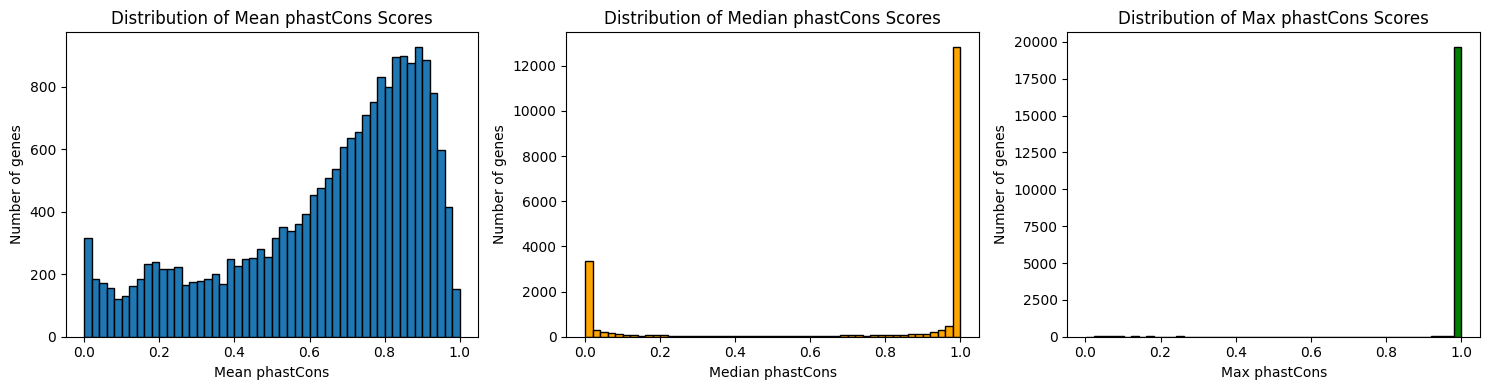

In [16]:
# Plot distribution of phastCons scores
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean phastCons
axes[0].hist(df_results['mean_phastCons'].dropna(), bins=50, edgecolor='black')
axes[0].set_xlabel('Mean phastCons')
axes[0].set_ylabel('Number of genes')
axes[0].set_title('Distribution of Mean phastCons Scores')

# Median phastCons
axes[1].hist(df_results['median_phastCons'].dropna(), bins=50, edgecolor='black', color='orange')
axes[1].set_xlabel('Median phastCons')
axes[1].set_ylabel('Number of genes')
axes[1].set_title('Distribution of Median phastCons Scores')

# Max phastCons
axes[2].hist(df_results['max_phastCons'].dropna(), bins=50, edgecolor='black', color='green')
axes[2].set_xlabel('Max phastCons')
axes[2].set_ylabel('Number of genes')
axes[2].set_title('Distribution of Max phastCons Scores')

plt.tight_layout()
plt.show()

In [17]:
# Check some well-known genes
test_genes = ['BRCA1', 'TP53', 'MECP2', 'SCN2A', 'CACNA1C']
print("\nphastCons scores for well-known genes:")
print("=" * 80)
for gene in test_genes:
    gene_data = df_results[df_results['GeneSymbol'] == gene]
    if not gene_data.empty:
        row = gene_data.iloc[0]
        print(f"{gene}:")
        print(f"  Entrez ID: {row['EntrezID']}")
        print(f"  Mean: {row['mean_phastCons']:.4f}, Median: {row['median_phastCons']:.4f}, Max: {row['max_phastCons']:.4f}")
        print(f"  CDS bases: {row['n_CDS_bases']}")
    else:
        print(f"{gene}: Not found")


phastCons scores for well-known genes:
BRCA1:
  Entrez ID: 672
  Mean: 0.3977, Median: 0.0570, Max: 1.0000
  CDS bases: 5733
TP53:
  Entrez ID: 7157
  Mean: 0.5172, Median: 0.5620, Max: 1.0000
  CDS bases: 1363
MECP2:
  Entrez ID: 4204
  Mean: 0.8962, Median: 1.0000, Max: 1.0000
  CDS bases: 1560
SCN2A:
  Entrez ID: 6326
  Mean: 0.9171, Median: 1.0000, Max: 1.0000
  CDS bases: 6107
CACNA1C:
  Entrez ID: 775
  Mean: 0.8594, Median: 1.0000, Max: 1.0000
  CDS bases: 7326


In [18]:
# Top 20 most conserved genes by mean phastCons
print("\nTop 20 most conserved genes (by mean phastCons):")
print("=" * 80)
top_conserved = df_results.nlargest(20, 'mean_phastCons')[['GeneSymbol', 'EntrezID', 'mean_phastCons', 'median_phastCons', 'max_phastCons', 'n_CDS_bases']]
print(top_conserved.to_string(index=False))


Top 20 most conserved genes (by mean phastCons):
   GeneSymbol EntrezID  mean_phastCons  median_phastCons  max_phastCons  n_CDS_bases
   AL354993.1     None        0.999977               1.0            1.0          222
        RPL41     6171        0.999733               1.0            1.0           75
       UBE2NL     None        0.999235               1.0            1.0          459
      SYNCRIP    10492        0.999138               1.0            1.0          290
         IGIP   492311        0.998660               1.0            1.0          159
        SUMO2     6613        0.998284               1.0            1.0          285
       UBE2D2     7322        0.997923               1.0            1.0          441
      CAMK2N2    94032        0.997819               1.0            1.0          237
     SUMO2P21     None        0.997747               1.0            1.0          285
         LCOR    84458        0.997607               1.0            1.0         1303
      C1orf21  

## Summary

**Outputs:**
1. `phastCons_scores_all_genes.csv` - All protein-coding genes
2. `phastCons_scores_all_genes_EntrezOnly.csv` - Only genes with Entrez IDs

**Columns:**
- `EnsemblID`: Ensembl gene ID
- `EntrezID`: Entrez gene ID (if available)
- `GeneSymbol`: Gene symbol
- `Chromosome`: Chromosome location
- `mean_phastCons`: Mean phastCons score across all CDS bases
- `median_phastCons`: Median phastCons score
- `max_phastCons`: Maximum phastCons score
- `n_CDS_bases`: Total number of CDS bases (merged)